# 6. Multivariate EDA <a id="6-multivariate-eda" name="6-multivariate-eda"></a>

In [ ]:
# Genre explosion for multivariate analysis:
# We cannot analyze by genre if everything is in a single cell, for example df["genre"] = "Action, Thriller, Drama".
# Therefore, we need to explode each movie into as many rows as it has genres.
genre_rows = []
for _, row in df.iterrows():
    for g in str(row["genres"]).split(","):
        g = g.strip()
        if g:
            genre_rows.append({
                "title": row["title"], "genre": g,
                "vote_average": row["vote_average"], "vote_count": row["vote_count"],
                "runtime": row["runtime"], "budget": row["budget"], "revenue": row["revenue"],
                "release_year": row["release_year"], "release_decade": row["release_decade"],
                "popularity": row["popularity"], "weighted_rating": row["weighted_rating"],
                "director": row["director"], "production_countries": row["production_countries"],
            })
df_ge = pd.DataFrame(genre_rows)

# Average rating per genre
genre_stats = df_ge.groupby("genre").agg(
    total_films=("title","count"),
    avg_rating=("vote_average","mean"),
    median_rating=("vote_average","median"),
    avg_votes=("vote_count","mean"),
    avg_runtime=("runtime","mean"),
    avg_popularity=("popularity","mean"),
).round(2).sort_values("avg_rating", ascending=False)

print("Genre Statistics (sorted by avg rating):")
display(genre_stats.head(15))

Genre Statistics (sorted by avg rating):


,total_films,avg_rating,median_rating,avg_votes,avg_runtime,avg_popularity
genre,,,,,,
Documentary,196,7.24,7.30,324.53,103.49,3.21
Animation,572,7.23,7.30,2906.96,91.13,9.57
History,341,7.18,7.20,1885.67,132.10,5.32
Drama,2342,7.14,7.26,2377.26,117.36,6.32
Music,287,7.08,7.06,1062.12,108.81,4.92
War,278,7.08,7.13,2029.65,127.69,5.22
Romance,839,6.97,7.00,2129.75,111.67,6.69
Crime,807,6.95,6.96,2890.34,114.24,7.31
Family,635,6.92,6.95,3195.45,95.06,9.04


**Documentary and historical films** generally have the highest ratings > niche audience.

**Horror and action films** often have the lowest ratings > broader but less demanding audience.

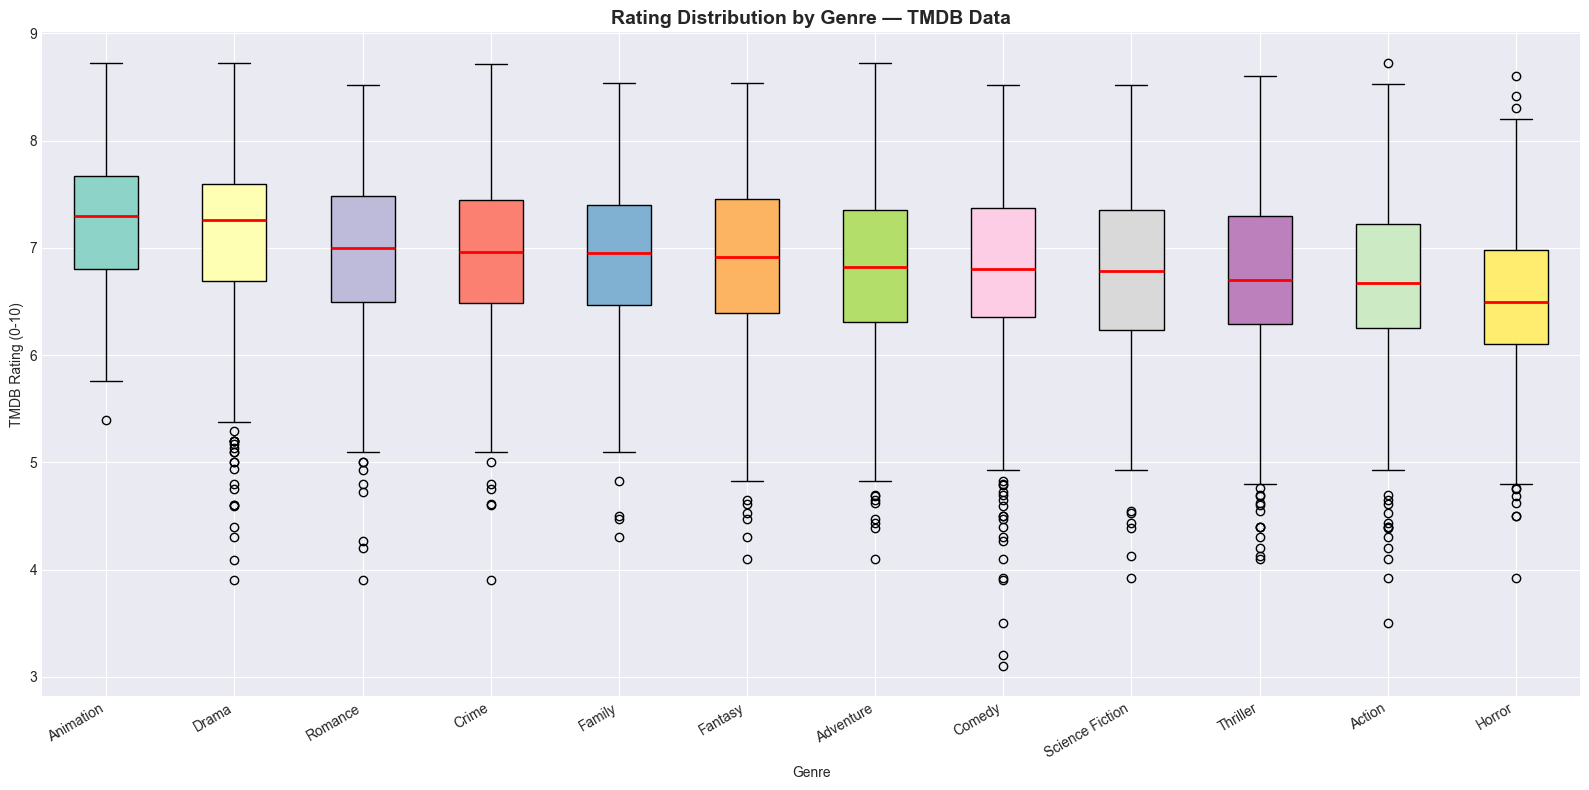

In [ ]:
# Boxplot: Rating by genre
top_genres = genre_counts.head(12).index.tolist()
df_top = df_ge[df_ge["genre"].isin(top_genres)]

fig, ax = plt.subplots(figsize=(16, 8))
genre_order = df_top.groupby("genre")["vote_average"].median().sort_values(ascending=False).index
df_top_sorted = df_top[df_top["genre"].isin(genre_order)]

bp_data = [df_top_sorted[df_top_sorted["genre"]==g]["vote_average"].values for g in genre_order]
bp = ax.boxplot(bp_data, labels=genre_order, patch_artist=True, notch=False,
                medianprops=dict(color="red", linewidth=2))
colors = plt.cm.Set3(np.linspace(0, 1, len(genre_order)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_title("Rating Distribution by Genre — TMDB Data", fontsize=14, fontweight="bold")
ax.set_xlabel("Genre"); ax.set_ylabel("TMDB Rating (0-10)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../exports/fig_04_genre_rating_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


**Animation :**

Median ~7.3. Narrow box; lower whisker ~5.3. Animated films are consistently good studios like Disney and Studio Ghibli pull up the overall level. Only one low outlier around ~5.3, almost no bad movies in Animation.

**Drama :**

Most reliable. Median = 7.3, medium box width. Outliers : many low outliers. While the median matches Animation, the box is wider with many low outliers (4.0–5.0). This is expected since Drama is the most common genre, leading to higher variance.

**Crime + Romance :**

Crime is underrated with a very high median and few outliers, crime thrillers attract a demanding audience. High ratings for Romance suggest these films are generally well-received by their targeted audience.

**Comedy :**

Very wide box; outliers extend down to 3, showing high rating variability.

**Horror :**

The most extreme genre—outliers on both sides and a very wide box. Films tend to be either terrible or excellent.

**Action + Thriller + Science Fiction :**

Wide boxes with a lower median across all three mainstream commercial genres > a broader audience often translates to less demanding overall ratings.

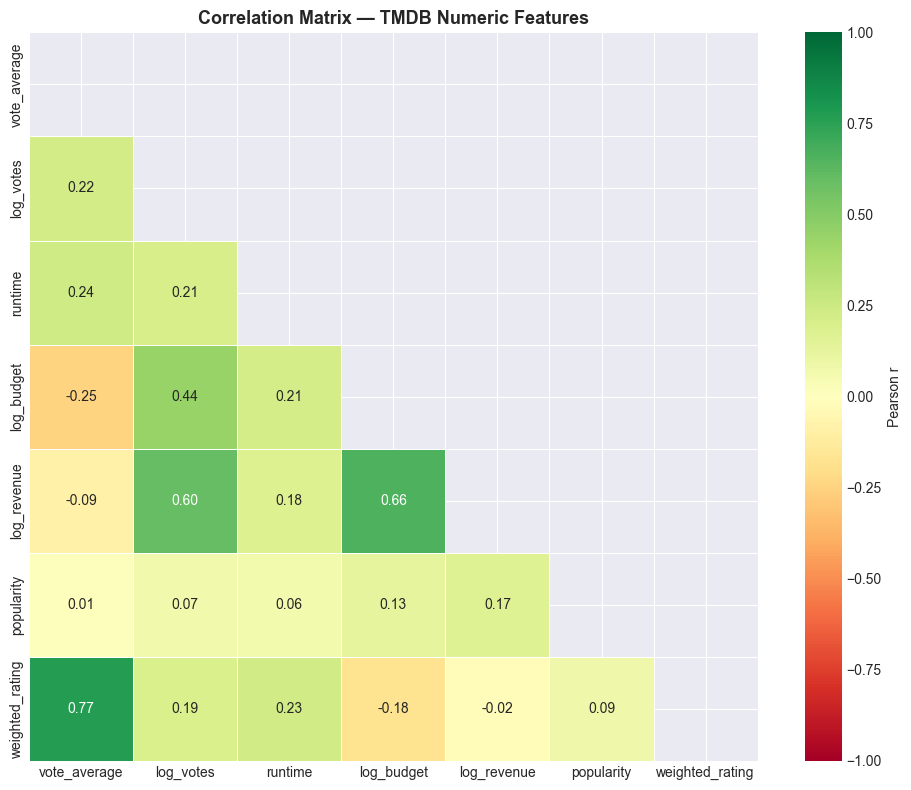


 Key correlations with vote_average:
vote_average       1.00
weighted_rating    0.77
runtime            0.24
log_votes          0.22
popularity         0.01
log_revenue       -0.09
log_budget        -0.25


In [ ]:
# Correlation heatmap
num_cols = ["vote_average","vote_count","runtime","budget","revenue","popularity","weighted_rating","n_genres"]
df_corr = df[num_cols].copy()
df_corr["log_votes"]   = np.log10(df_corr["vote_count"] + 1)
df_corr["log_budget"]  = np.log10(df_corr["budget"].replace(0, np.nan))
df_corr["log_revenue"] = np.log10(df_corr["revenue"].replace(0, np.nan))

corr = df_corr[["vote_average","log_votes","runtime","log_budget","log_revenue","popularity","weighted_rating"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, ax=ax, linewidths=0.5, square=True, vmin=-1, vmax=1, center=0,
            cbar_kws={"label":"Pearson r"})
ax.set_title("Correlation Matrix — TMDB Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../exports/fig_05_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Key correlations with vote_average:")
print(corr["vote_average"].sort_values(ascending=False).to_string())

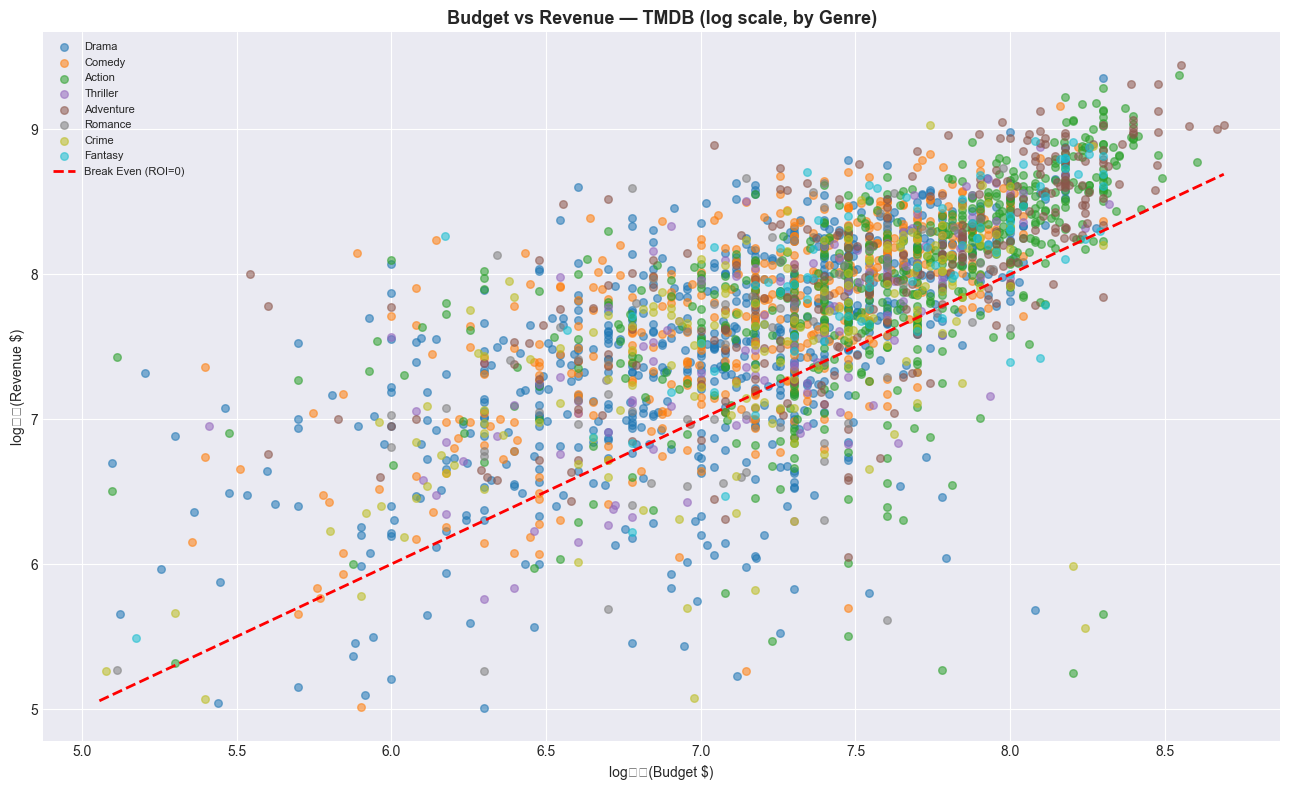

In [ ]:
# Budget vs Revenue scatter
df_br = df[(df["budget"]>100_000) & (df["revenue"]>100_000)].copy()
df_br["log_budget"]  = np.log10(df_br["budget"])
df_br["log_revenue"] = np.log10(df_br["revenue"])

fig, ax = plt.subplots(figsize=(13, 8))
top8g = genre_counts.head(8).index.tolist()
colors_g = plt.cm.tab10(np.linspace(0, 1, 8))
for i, g in enumerate(top8g):
    mask = df_br["primary_genre"] == g
    ax.scatter(df_br[mask]["log_budget"], df_br[mask]["log_revenue"],
               alpha=0.55, label=g, color=colors_g[i], s=30)
x_r = np.linspace(df_br["log_budget"].min(), df_br["log_budget"].max(), 100)
ax.plot(x_r, x_r, "r--", lw=2, label="Break Even (ROI=0)")
ax.set_title("Budget vs Revenue — TMDB (log scale, by Genre)", fontsize=13, fontweight="bold")
ax.set_xlabel("log₁₀(Budget $)"); ax.set_ylabel("log₁₀(Revenue $)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../exports/fig_06_budget_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

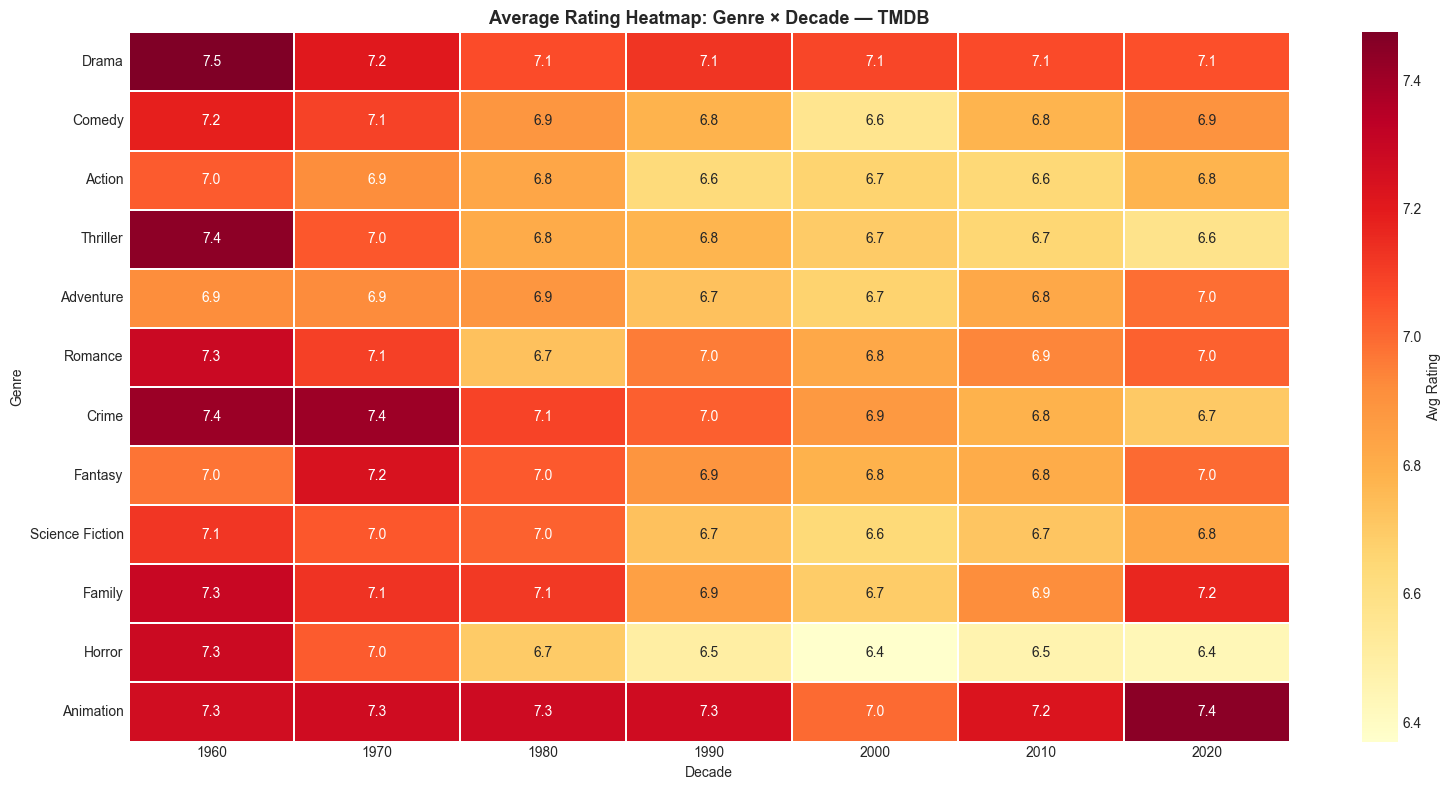

In [ ]:
# Genre × Decade heatmap
pivot = df_ge.groupby(["release_decade","genre"])["vote_average"].mean().unstack()
top_g = genre_counts.head(12).index.tolist()
pivot = pivot[[g for g in top_g if g in pivot.columns]]
pivot = pivot[pivot.index >= 1960].dropna(how="all")

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot.T, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=ax, linewidths=0.3, cbar_kws={"label":"Avg Rating"})
ax.set_title("Average Rating Heatmap: Genre × Decade — TMDB", fontsize=13, fontweight="bold")
ax.set_xlabel("Decade"); ax.set_ylabel("Genre")
plt.tight_layout()
plt.savefig("../exports/fig_07_heatmap_genre_decade.png", dpi=150, bbox_inches="tight")
plt.show()
